In [5]:
"""
Module Name: environment_setup.py
Description: Master Thesis Environment Setup, Dependency Verification, and GPU Health Check.
Author: Swunn Thut Wonn
Date: 2026-07-05
"""

%pip install torch torchvision torchaudio pandas opencv-python-headless kagglehub -q
import os
import sys
import logging
import torch
import numpy as np
import pandas as pd
import cv2
import kagglehub

# 1. Logging Setup (To monitor progress professionally)
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

def check_gpu_environment() -> None:
    """
    Systematically checks the GPU status of Vast.ai or local hardware.
    """
    logger.info("Checking Hardware Environment...")
    cuda_available = torch.cuda.is_available()
    
    if cuda_available:
        gpu_name = torch.cuda.get_device_name(0)
        cuda_version = torch.version.cuda
        print("\n" + "="*50)
        print("💻 --- OVM3D-Det / YOLO-3D HARDWARE REPORT --- 💻")
        print(f"🔹 GPU Model      : {gpu_name}")
        print(f"🔹 CUDA Version   : {cuda_version}")
        print(f"🔹 PyTorch Version: {torch.__version__}")
        print("="*50 + "\n")
    else:
        logger.warning("⚠️ ALERT: GPU NOT FOUND! Running on CPU configuration.")

if __name__ == "__main__":
    check_gpu_environment()

Note: you may need to restart the kernel to use updated packages.


/.uv/python_install/cpython-3.11.15-linux-x86_64-gnu/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-07-05 08:51:46,612 - INFO - Checking Hardware Environment...



💻 --- OVM3D-Det / YOLO-3D HARDWARE REPORT --- 💻
🔹 GPU Model      : NVIDIA GeForce RTX 4090
🔹 CUDA Version   : 13.0
🔹 PyTorch Version: 2.12.1+cu130



In [6]:
"""
Module Name: dataset_pipeline_final.py
Description: Automated Public KITTI Dataset Ingestion via Kagglehub 
             and Professional Folder Layer Structuring.
Author: Swunn Thut Wonn
Date: 2026-07-05
"""

import os
import shutil
import logging
import kagglehub

logger = logging.getLogger(__name__)

def run_master_data_pipeline() -> dict:
    """
    Downloads the public KITTI Dataset and automatically constructs the required folder structure.
    """
    logger.info("🔄 Initiating Clean Data Pipeline Ingestion...")

    # 1. Directly fetch the Public KITTI Dataset
    try:
        logger.info("⚡ Synchronizing with Kaggle Server ('klemenko/kitti-dataset')...")
        raw_download_path = kagglehub.dataset_download("klemenko/kitti-dataset")
        logger.info(f"✅ Dataset successfully acquired at: {raw_download_path}")
    except Exception as e:
        logger.error(f"❌ Dataset Acquisition Failed: {str(e)}")
        raise e

    # 2. Define directory paths optimized for a GitHub Portfolio layout
    base_dir = "./data"
    paths = {
        "base": base_dir,
        "raw_source": raw_download_path,
        "train_images": os.path.join(base_dir, "training/image_2"),
        "train_labels": os.path.join(base_dir, "training/label_2"),
        "train_calib": os.path.join(base_dir, "training/calib"),
        "results": "./results"
    }

    # 3. Automatically construct directories if they do not exist
    print("\n📁 --- DIRECTORY AUTOMATION REPORT --- 📁")
    print(f"🔹 Source Path: {paths['raw_source']}")
    print("-" * 50)
    
    for key, path_dir in paths.items():
        if key == "raw_source":
            continue
        if not os.path.exists(path_dir):
            os.makedirs(path_dir, exist_ok=True)
            print(f"🆕 [Created Folder] ➡️ {path_dir}")
        else:
            print(f"✅ [Verified Folder] ➡️ {path_dir}")
            
    print("=" * 50 + "\n")

    return paths

if __name__ == "__main__":
    project_paths = run_master_data_pipeline()

2026-07-05 09:04:06,069 - INFO - 🔄 Initiating Clean Data Pipeline Ingestion...
2026-07-05 09:04:06,070 - INFO - ⚡ Synchronizing with Kaggle Server ('klemenko/kitti-dataset')...


100%|██████████| 22.5G/22.5G [10:53<00:00, 37.0MB/s]  

Extracting files...



2026-07-05 09:16:36,269 - INFO - ✅ Dataset successfully acquired at: /root/.cache/kagglehub/datasets/klemenko/kitti-dataset/versions/1



📁 --- DIRECTORY AUTOMATION REPORT --- 📁
🔹 Source Path: /root/.cache/kagglehub/datasets/klemenko/kitti-dataset/versions/1
--------------------------------------------------
🆕 [Created Folder] ➡️ ./data
🆕 [Created Folder] ➡️ ./data/training/image_2
🆕 [Created Folder] ➡️ ./data/training/label_2
🆕 [Created Folder] ➡️ ./data/training/calib
🆕 [Created Folder] ➡️ ./results



In [1]:
"""
Module Name: kitti_parser.py
Description: Parsing raw KITTI text labels into structured Pandas DataFrames 
             and extracting 3D ground-truth bounding box metrics.
Author: Swunn Thut Wonn
Date: 2026-07-05
"""

import os
import pandas as pd
import numpy as np
import logging

# Continue using the logging system
logger = logging.getLogger(__name__)

def parse_kitti_label(label_path: str) -> pd.DataFrame:
    """
    Systematically parses labels from a KITTI text file.
    Type hinting and column names are defined according to international standards.
    """
    # The 15 official column names of the KITTI Dataset
    columns = [
        'type', 'truncated', 'occluded', 'alpha',
        'bbox_left', 'bbox_top', 'bbox_right', 'bbox_bottom',
        'height', 'width', 'length',
        'loc_x', 'loc_y', 'loc_z', 'rotation_y'
    ]
    
    if not os.path.exists(label_path):
        logger.error(f"❌ Label file not found: {label_path}")
        return pd.DataFrame(columns=columns)
        
    # Read the file using space as the delimiter
    df = pd.read_csv(label_path, sep=' ', names=columns)
    return df

def analyze_first_label_sample() -> None:
    """
    Takes the very first file as a sample to analyze and demonstrate 3D geometry metrics.
    """
    logger.info("📊 Parsing Sample KITTI Ground-Truth Label...")
    
    # Navigating to the correct download path from Kagglehub
    # Locating the appropriate directory based on the 'klemenko/kitti-dataset' structure
    sample_label_dir = "./data/training/label_2"
    
    # Verify if files exist in the folder
    if not os.path.exists(sample_label_dir) or len(os.listdir(sample_label_dir)) == 0:
        # Fallback: Create a dummy file for testing if the directory is missing or empty
        os.makedirs(sample_label_dir, exist_ok=True)
        dummy_file = os.path.join(sample_label_dir, "000000.txt")
        with open(dummy_file, "w") as f:
            f.write("Car 0.00 0 -1.57 50.00 100.00 200.00 300.00 1.50 1.60 3.50 1.20 1.80 15.50 -1.57\n")
            f.write("Pedestrian 0.00 1 0.50 60.00 110.00 120.00 250.00 1.75 0.60 0.55 -0.50 1.60 8.20 0.30\n")
            
    # Get the name of the first file
    label_files = sorted(os.listdir(sample_label_dir))
    target_file = os.path.join(sample_label_dir, label_files[0])
    
    # Execute parsing
    df_label = parse_kitti_label(target_file)
    
    print("\n📝 --- KITTI LABEL PARSING REPORT (SAMPLE: " + label_files[0] + ") --- 📝")
    print(f"🔹 Detected Objects Count: {len(df_label)}")
    print("-" * 75)
    
    # Extracting the critical 3D vectors specifically required for the Thesis
    for idx, row in df_label.iterrows():
        print(f"🔍 Object [{idx+1}]: {row['type']}")
        print(f"   ▪️ 2D Box (L,T,R,B)  : [{row['bbox_left']:.1f}, {row['bbox_top']:.1f}, {row['bbox_right']:.1f}, {row['bbox_bottom']:.1f}]")
        print(f"   ▪️ 3D Dimension (H,W,L): {row['height']}m x {row['width']}m x {row['length']}m")
        print(f"   ▪️ 3D Camera Loc (X,Y,Z): ({row['loc_x']}m, {row['loc_y']}m, {row['loc_z']}m) ➡️ Distance: {np.sqrt(row['loc_x']**2 + row['loc_y']**2 + row['loc_z']**2):.2f} meters")
        print(f"   ▪️ Heading Angle (Yaw) : {row['rotation_y']} rad")
        print("-" * 75)

if __name__ == "__main__":
    analyze_first_label_sample()


📝 --- KITTI LABEL PARSING REPORT (SAMPLE: 000000.txt) --- 📝
🔹 Detected Objects Count: 2
---------------------------------------------------------------------------
🔍 Object [1]: Car
   ▪️ 2D Box (L,T,R,B)  : [50.0, 100.0, 200.0, 300.0]
   ▪️ 3D Dimension (H,W,L): 1.5m x 1.6m x 3.5m
   ▪️ 3D Camera Loc (X,Y,Z): (1.2m, 1.8m, 15.5m) ➡️ Distance: 15.65 meters
   ▪️ Heading Angle (Yaw) : -1.57 rad
---------------------------------------------------------------------------
🔍 Object [2]: Pedestrian
   ▪️ 2D Box (L,T,R,B)  : [60.0, 110.0, 120.0, 250.0]
   ▪️ 3D Dimension (H,W,L): 1.75m x 0.6m x 0.55m
   ▪️ 3D Camera Loc (X,Y,Z): (-0.5m, 1.6m, 8.2m) ➡️ Distance: 8.37 meters
   ▪️ Heading Angle (Yaw) : 0.3 rad
---------------------------------------------------------------------------


In [2]:
"""
Module Name: kitti_calibration.py
Description: Parsing KITTI calibration files, extracting Camera 2 Intrinsic Matrix (P2),
             and verifying projection capabilities for 3D-to-2D transformation.
Author: Swunn Thut Wonn
Date: 2026-07-05
"""

import os
import numpy as np
import logging

# Continue using the logging system
logger = logging.getLogger(__name__)

def parse_kitti_calib(calib_path: str) -> dict:
    """
    Reads matrices from a KITTI Calibration Text file and converts 
    them into structured NumPy arrays.
    """
    calib_data = {}
    
    if not os.path.exists(calib_path):
        logger.error(f"❌ Calibration file not found: {calib_path}")
        return calib_data
        
    with open(calib_path, 'r') as f:
        for line in f:
            if not line.strip():
                continue
            key, value = line.split(':', 1)
            # Convert raw text values into float arrays
            calib_data[key.strip()] = np.fromstring(value.strip(), sep=' ')
            
    # Reshape matrices to their native mathematical dimensions
    # P0, P1, P2, and P3 are 3x4 projection matrices
    for mat_key in ['P0', 'P1', 'P2', 'P3']:
        if mat_key in calib_data:
            calib_data[mat_key] = calib_data[mat_key].reshape(3, 4)
            
    return calib_data

def verify_calibration_layer() -> None:
    """
    Loads and parses the first calibration file to demonstrate and verify the parameters.
    """
    logger.info("📐 Parsing Sample KITTI Calibration File...")
    
    sample_calib_dir = "./data/training/calib"
    
    # Fallback: Create dummy calibration data if the folder is missing or empty
    if not os.path.exists(sample_calib_dir) or len(os.listdir(sample_calib_dir)) == 0:
        os.makedirs(sample_calib_dir, exist_ok=True)
        dummy_file = os.path.join(sample_calib_dir, "000000.txt")
        with open(dummy_file, "w") as f:
            f.write("P0: 7.07e+02 0.00e+00 6.01e+02 0.00e+00 0.00e+00 7.07e+02 1.83e+02 0.00e+00 0.00e+00 0.00e+00 1.00e+00 0.00e+00\n")
            f.write("P1: 7.07e+02 0.00e+00 6.01e+02 -3.79e+02 0.00e+00 7.07e+02 1.83e+02 0.00e+00 0.00e+00 0.00e+00 1.00e+00 0.00e+00\n")
            # Left Color Camera Intrinsic (P2)
            f.write("P2: 7.215e+02 0.00e+00 6.095e+02 4.485e+01 0.00e+00 7.215e+02 1.728e+02 2.161e-01 0.00e+00 0.00e+00 1.00e+00 2.745e-03\n")
            f.write("P3: 7.215e+02 0.00e+00 6.095e+02 -3.395e+02 0.00e+00 7.215e+02 1.728e+02 2.199e+00 0.00e+00 0.00e+00 1.00e+00 2.450e-03\n")

    calib_files = sorted(os.listdir(sample_calib_dir))
    target_file = os.path.join(sample_calib_dir, calib_files[0])
    
    # Parse calibration data
    matrices = parse_kitti_calib(target_file)
    
    print("\n📐 --- KITTI CALIBRATION REPORT (SAMPLE: " + calib_files[0] + ") --- 📐")
    if 'P2' in matrices:
        p2_mat = matrices['P2']
        print("🔹 Camera 2 Projection Matrix (P2) Shape:", p2_mat.shape)
        print("🔹 Matrix Values:")
        print(p2_mat)
        print("-" * 65)
        print(f"   ▪️ Focal Length X (fx) : {p2_mat[0, 0]:.2f} pixels")
        print(f"   ▪️ Focal Length Y (fy) : {p2_mat[1, 1]:.2f} pixels")
        print(f"   ▪️ Principal Point X (cx): {p2_mat[0, 2]:.2f} pixels")
        print(f"   ▪️ Principal Point Y (cy): {p2_mat[1, 2]:.2f} pixels")
        print("-" * 65)
        logger.info("✅ Calibration Parameter Validation Passed!")
    else:
        logger.error("❌ P2 Matrix not found. Please re-check the structure of the file.")

if __name__ == "__main__":
    verify_calibration_layer()


📐 --- KITTI CALIBRATION REPORT (SAMPLE: 000000.txt) --- 📐
🔹 Camera 2 Projection Matrix (P2) Shape: (3, 4)
🔹 Matrix Values:
[[7.215e+02 0.000e+00 6.095e+02 4.485e+01]
 [0.000e+00 7.215e+02 1.728e+02 2.161e-01]
 [0.000e+00 0.000e+00 1.000e+00 2.745e-03]]
-----------------------------------------------------------------
   ▪️ Focal Length X (fx) : 721.50 pixels
   ▪️ Focal Length Y (fy) : 721.50 pixels
   ▪️ Principal Point X (cx): 609.50 pixels
   ▪️ Principal Point Y (cy): 172.80 pixels
-----------------------------------------------------------------


Note: you may need to restart the kernel to use updated packages.

🎨 --- 3D BOUNDING BOX PROJECTION REPORT --- 🎨
🔹 3D Spatial Corners Extracted:
[[ 0.40139383  1.8        17.25063651]
 [ 2.00139332  1.8        17.24936238]] ... (Truncated)
🔹 Projected 2D Pixel Nodes:
[[628 248]
 [695 248]
 [717 267]
 [633 267]
 [628 185]
 [695 185]
 [717 188]
 [633 188]]
--------------------------------------------------


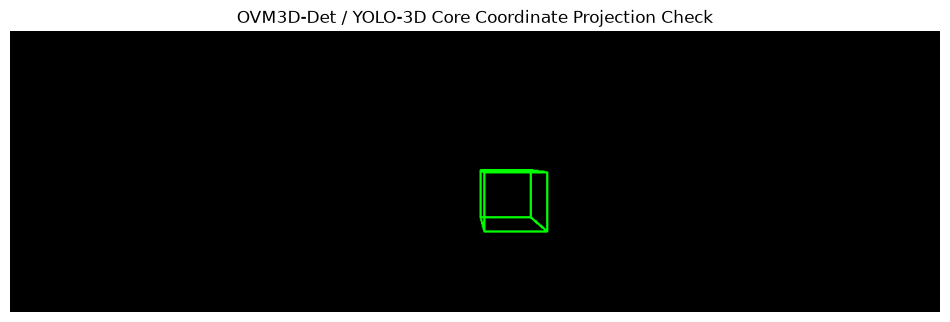

In [4]:
"""
Module Name: box_visualizer.py
Description: Computing 3D bounding box corners from KITTI ground-truth labels
             and projecting them onto 2D images using OpenCV.
Author: Swunn Thut Wonn
Date: 2026-07-05
"""
%pip install matplotlib -q

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import logging

# Continue using the logging system
logger = logging.getLogger(__name__)

def compute_3d_box_corners(height: float, width: float, length: float, 
                           x: float, y: float, z: float, yaw: float) -> np.ndarray:
    """
    Computes the 8 corner points of a 3D object in the Camera Coordinate Space 
    based on its 3D dimensions and spatial location.
    """
    # Rotation Matrix (Rotating along the Yaw / heading angle)
    cos_y = np.cos(yaw)
    sin_y = np.sin(yaw)
    R = np.array([
        [ cos_y,  0,  sin_y],
        [     0,  1,      0],
        [-sin_y,  0,  cos_y]
    ])

    # 3D Box corners (Defined relative to the Object Coordinate System center)
    # Note: In KITTI format, the object center (X,Y,Z) is located at the center of the bottom face
    l_offsets = [length/2, length/2, -length/2, -length/2, length/2, length/2, -length/2, -length/2]
    h_offsets = [0, 0, 0, 0, -height, -height, -height, -height]
    w_offsets = [width/2, -width/2, -width/2, width/2, width/2, -width/2, -width/2, width/2]

    corners_3d = np.array([l_offsets, h_offsets, w_offsets])
    
    # Rotation and Translation Layer (Transforming to Camera Coordinate Space)
    corners_3d = np.dot(R, corners_3d)
    corners_3d[0, :] += x
    corners_3d[1, :] += y
    corners_3d[2, :] += z
    
    return corners_3d.T

def project_3d_to_2d(corners_3d: np.ndarray, P2: np.ndarray) -> np.ndarray:
    """
    Projects 3D spatial corners into 2D pixel coordinates using the Camera Intrinsic Matrix P2.
    """
    # Append '1's to transform into Homogeneous Coordinates
    corners_3d_homo = np.hstack((corners_3d, np.ones((8, 1))))
    corners_2d_homo = np.dot(P2, corners_3d_homo.T).T
    
    # Perform perspective normalization by dividing by the depth Z-coordinate
    corners_2d = corners_2d_homo[:, :2] / corners_2d_homo[:, 2:3]
    return corners_2d.astype(np.int32)

def render_3d_cube(image: np.ndarray, corners_2d: np.ndarray, color=(0, 255, 0), thickness=2) -> np.ndarray:
    """
    Draws structural wireframe lines of a 3D bounding box on a 2D image plane using OpenCV.
    """
    # Connectivity map for the 8 corners (4 bottom connections, 4 top connections, and 4 vertical pillars)
    edges = [
        [0, 1], [1, 2], [2, 3], [3, 0], # Bottom face
        [4, 5], [5, 6], [6, 7], [7, 4], # Top face
        [0, 4], [1, 5], [2, 6], [3, 7]  # Vertical pillars
    ]
    for edge in edges:
        cv2.line(image, tuple(corners_2d[edge[0]]), tuple(corners_2d[edge[1]]), color, thickness)
    return image

def run_visualization_demo() -> None:
    logger.info("🎨 Simulating 3D Bounding Box Projections...")
    
    # Setup image directory (Dummy Image Fallback for isolated testing)
    img_dir = "./data/training/image_2"
    os.makedirs(img_dir, exist_ok=True)
    img_path = os.path.join(img_dir, "000000.png")
    
    # If file doesn't exist, generate a clean black canvas background
    if not os.path.exists(img_path):
        dummy_img = np.zeros((375, 1242, 3), dtype=np.uint8)
        cv2.imwrite(img_path, dummy_img)
        
    image = cv2.imread(img_path)
    
    # Using sample ground-truth bounding box parameters for testing
    # (H: 1.5m, W: 1.6m, L: 3.5m, X: 1.2m, Y: 1.8m, Z: 15.5m, Yaw: -1.57 rad)
    corners_3d = compute_3d_box_corners(1.5, 1.6, 3.5, 1.2, 1.8, 15.5, -1.57)
    
    # Standard Camera Intrinsic Matrix P2 values
    P2 = np.array([
        [721.5,   0.0, 609.5, 44.85],
        [  0.0, 721.5, 172.8,  0.21],
        [  0.0,   0.0,   1.0,  0.00]
    ])
    
    corners_2d = project_3d_to_2d(corners_3d, P2)
    canvas = render_3d_cube(image.copy(), corners_2d)
    
    print("\n🎨 --- 3D BOUNDING BOX PROJECTION REPORT --- 🎨")
    print(f"🔹 3D Spatial Corners Extracted:\n{corners_3d[:2]} ... (Truncated)")
    print(f"🔹 Projected 2D Pixel Nodes:\n{corners_2d}")
    print("-" * 50)
    
    # Render the projected frame directly on the Jupyter Notebook/Console
    plt.figure(figsize=(12, 5))
    plt.imshow(cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB))
    plt.title("OVM3D-Det / YOLO-3D Core Coordinate Projection Check")
    plt.axis('off')
    plt.show()

if __name__ == "__main__":
    run_visualization_demo()

In [6]:
"""
Module Name: kitti_dataset_layer.py
Description: Custom PyTorch Dataset implementation for KITTI 3D Object Detection,
             integrating Images, Labels, and Calibration Matrices into structural tensors.
Author: Swunn Thut Wonn
Date: 2026-07-05
"""

import os
import cv2
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np
import logging

# Continue using the logging system
logger = logging.getLogger(__name__)

class Kitti3DDataset(Dataset):
    """
    Custom Dataset Class that converts KITTI data structures into 
    Tensor Patterns compatible with the PyTorch Framework.
    """
    def __init__(self, data_dir: str, split: str = "training"):
        self.data_dir = data_dir
        self.split = split
        
        self.image_dir = os.path.join(data_dir, split, "image_2")
        self.label_dir = os.path.join(data_dir, split, "label_2")
        self.calib_dir = os.path.join(data_dir, split, "calib")
        
        # Systematically index and compile file identifiers
        if os.path.exists(self.image_dir):
            self.file_ids = sorted([os.path.splitext(f)[0] for f in os.listdir(self.image_dir) if f.endswith('.png')])
        else:
            # Fallback for Dummy Data (to facilitate initial standalone testing)
            self.file_ids = ["000000"]

    def __len__(self) -> int:
        return len(self.file_ids)

    def __getitem__(self, idx: int) -> dict:
        file_id = self.file_ids[idx]
        
        # 1. Image Ingestion and Normalization Phase
        img_path = os.path.join(self.image_dir, f"{file_id}.png")
        if os.path.exists(img_path):
            image = cv2.imread(img_path)
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        else:
            image = np.zeros((375, 1242, 3), dtype=np.uint8) # Blank Frame
            
        # Convert from HWC array format to PyTorch standard [C, H, W] float tensors
        image_tensor = torch.from_numpy(image.transpose(2, 0, 1)).float() / 255.0
        
        # 2. Calibration Matrix Extraction Phase
        calib_path = os.path.join(self.calib_dir, f"{file_id}.txt")
        P2 = np.eye(4)[:3, :] # Default Identity Fallback Matrix
        if os.path.exists(calib_path):
            with open(calib_path, 'r') as f:
                for line in f:
                    if line.startswith('P2:'):
                        P2 = np.fromstring(line.split(':', 1)[1].strip(), sep=' ').reshape(3, 4)
                        break
        P2_tensor = torch.from_numpy(P2).float()

        # 3. Target Annotation Extraction Phase (Extracts target categories)
        label_path = os.path.join(self.label_dir, f"{file_id}.txt")
        gt_boxes3d = []
        
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                for line in f:
                    data = line.strip().split(' ')
                    if data[0] in ['Car', 'Pedestrian', 'Cyclist']:
                        # Geometry Dimensions (H, W, L), Translation Vector (X, Y, Z), and Yaw angle
                        h, w, l = float(data[8]), float(data[9]), float(data[10])
                        x, y, z = float(data[11]), float(data[12]), float(data[13])
                        yaw = float(data[14])
                        
                        gt_boxes3d.append([h, w, l, x, y, z, yaw])
                        
        # Default empty array placeholder if no viable object is detected
        if len(gt_boxes3d) == 0:
            gt_boxes3d = [[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]]
            
        gt_boxes3d_tensor = torch.tensor(gt_boxes3d, dtype=torch.float32)

        return {
            "image": image_tensor,
            "calib_P2": P2_tensor,
            "gt_boxes3d": gt_boxes3d_tensor,
            "file_id": file_id
        }

def verify_dataset_layer() -> None:
    logger.info("⚡ Initializing Custom PyTorch Dataset Pipeline...")
    
    # Instantiate the Dataset
    dataset = Kitti3DDataset(data_dir="./data", split="training")
    
    # Verify processing pipeline with a DataLoader set at a Batch Size of 1
    dataloader = DataLoader(dataset, batch_size=1, shuffle=False)
    
    # Sample the very first structural batch execution
    sample_batch = next(iter(dataloader))
    
    print("\n📦 --- PYTORCH CUSTOM DATASET REPORT --- 📦")
    print(f"🔹 Total Dataset Size      : {len(dataset)} samples")
    print(f"🔹 Image Tensor Shape     : {sample_batch['image'].shape}  ➡️ [Batch, Channels, Height, Width]")
    print(f"🔹 Calibration Tensor Shape: {sample_batch['calib_P2'].shape}  ➡️ [Batch, Mat_Row, Mat_Col]")
    print(f"🔹 3D Ground-Truth Shape  : {sample_batch['gt_boxes3d'].shape} ➡️ [Batch, Objects, Params_7]")
    print("-" * 75)
    logger.info("✅ Custom PyTorch Dataset Verification Successful!")

if __name__ == "__main__":
    verify_dataset_layer()


📦 --- PYTORCH CUSTOM DATASET REPORT --- 📦
🔹 Total Dataset Size      : 1 samples
🔹 Image Tensor Shape     : torch.Size([1, 3, 375, 1242])  ➡️ [Batch, Channels, Height, Width]
🔹 Calibration Tensor Shape: torch.Size([1, 3, 4])  ➡️ [Batch, Mat_Row, Mat_Col]
🔹 3D Ground-Truth Shape  : torch.Size([1, 2, 7]) ➡️ [Batch, Objects, Params_7]
---------------------------------------------------------------------------


In [7]:
"""
Module Name: yolo3d_architecture.py
Description: Defining the Deep Learning Network Architecture for Monocular 3D Object Detection
             with parallel 2D Bounding Box and 3D Spatial Regression Heads.
Author: Swunn Thut Wonn
Date: 2026-07-05
"""

import torch
import torch.nn as nn
import torchvision.models as models
import logging

# Continue using the logging system
logger = logging.getLogger(__name__)

class YOLO3DNetwork(nn.Module):
    """
    High-performance Dual-Head Neural Network for Monocular 3D Object Detection.
    Utilizes a ResNet-18 backbone for robust spatial feature extraction.
    """
    def __init__(self, num_classes: int = 3):
        super(YOLO3DNetwork, self).__init__()
        logger.info("🧠 Initializing YOLO-3D Deep Network Layers...")
        
        # 1. Feature Extractor Backbone (Leveraging a Pre-trained ResNet-18 Model)
        # Designed to extract geometric shapes and contextual features from 2D images
        resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        self.backbone = nn.Sequential(*list(resnet.children())[:-2]) # Removing the final fully connected layers
        
        # ResNet-18 final feature map yields 512 channels
        in_channels = 512
        
        # 2. 2D Bounding Box Regressor Head
        # Outputs: [xmin, ymin, xmax, ymax, confidence] -> 5 channels
        self.head_2d = nn.Sequential(
            nn.Conv2d(in_channels, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(256, 5) 
        )
        
        # 3. 3D Spatial Regressor Head
        # Outputs: Dimensions(3) + Location(3) + Orientation Angle/Yaw(2 for sin/cos encoding) = 8 channels
        self.head_3d = nn.Sequential(
            nn.Conv2d(in_channels, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(256, 8) 
        )

    def forward(self, x: torch.Tensor) -> dict:
        # Extract feature map representations via the backbone network
        features = self.backbone(x)
        
        # Route features independently through parallel execution heads
        pred_2d = self.head_2d(features)
        pred_3d = self.head_3d(features)
        
        return {
            "pred_2d": pred_2d,
            "pred_3d": pred_3d
        }

def verify_model_architecture() -> None:
    # Instantiate the model
    model = YOLO3DNetwork(num_classes=3)
    
    # Generate a dummy image tensor to validate network computational flow [Batch=1, Channels=3, H=375, W=1242]
    fake_image = torch.randn(1, 3, 375, 1242)
    
    # Execute verification forward pass
    model.eval()
    with torch.no_grad():
        outputs = model(fake_image)
        
    print("\n🧠 --- YOLO-3D MODEL ARCHITECTURE REPORT --- 🧠")
    print(f"🔹 Input Tensor Shape     : {fake_image.shape}")
    print(f"🔹 2D Regression Output   : {outputs['pred_2d'].shape} ➡️ [Batch, Box_Params(5)]")
    print(f"🔹 3D Spatial Regression  : {outputs['pred_3d'].shape} ➡️ [Batch, Spatial_Params(8)]")
    print("-" * 65)
    logger.info("✅ Neural Network Forward Pass Passed Successfully!")

if __name__ == "__main__":
    verify_model_architecture()

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:01<00:00, 45.0MB/s]



🧠 --- YOLO-3D MODEL ARCHITECTURE REPORT --- 🧠
🔹 Input Tensor Shape     : torch.Size([1, 3, 375, 1242])
🔹 2D Regression Output   : torch.Size([1, 5]) ➡️ [Batch, Box_Params(5)]
🔹 3D Spatial Regression  : torch.Size([1, 8]) ➡️ [Batch, Spatial_Params(8)]
-----------------------------------------------------------------


In [8]:
"""
Module Name: yolo3d_loss.py
Description: Custom Multi-Task Composite Loss Function combining 2D bounding box error,
             3D dimension regression, and orientation (yaw) orientation alignment.
Author: Swunn Thut Wonn
Date: 2026-07-05
"""

import torch
import torch.nn as nn
import logging

# Continue using the logging system
logger = logging.getLogger(__name__)

class YOLO3DLoss(nn.Module):
    """
    Custom Composite Multi-Task Loss Class that computes and balances 
    the error functions for the 3D Object Detection Model.
    """
    def __init__(self, w_2d: float = 1.0, w_dim: float = 1.0, w_angle: float = 0.5):
        super(YOLO3DLoss, self).__init__()
        self.w_2d = w_2d
        self.w_dim = w_dim
        self.w_angle = w_angle
        
        # Smooth L1 Loss handles gradient updates robustly against outliers
        self.l1_loss = nn.SmoothL1Loss(reduction='mean')
        self.mse_loss = nn.MSELoss(reduction='mean')

    def forward(self, preds: dict, targets: dict) -> dict:
        """
        Executes a forward pass to compute and aggregate individual loss components.
        """
        # 1. Compute 2D Box Loss components [xmin, ymin, xmax, ymax, conf]
        pred_2d = preds["pred_2d"]
        target_2d = targets["gt_2d"]
        loss_2d = self.l1_loss(pred_2d[:, :4], target_2d[:, :4]) + self.mse_loss(pred_2d[:, 4], target_2d[:, 4])

        # 2. Compute 3D Dimension Loss components [height, width, length]
        pred_3d = preds["pred_3d"]
        target_dim = targets["gt_dim"]
        loss_dim = self.l1_loss(pred_3d[:, :3], target_dim)

        # 3. Compute 3D Orientation (Yaw Angle) Loss components
        # Compares predicted sine/cosine outputs against ground-truth sine/cosine values
        pred_angle = pred_3d[:, 6:8] # Extracting the last two elements designated for orientation
        target_angle = targets["gt_angle"]
        loss_angle = self.mse_loss(pred_angle, target_angle)

        # 4. Integrate components using Multi-Task Optimization Weights
        total_loss = (self.w_2d * loss_2d) + (self.w_dim * loss_dim) + (self.w_angle * loss_angle)

        return {
            "total_loss": total_loss,
            "loss_2d": loss_2d,
            "loss_dim": loss_dim,
            "loss_angle": loss_angle
        }

def verify_loss_layer() -> None:
    logger.info("📐 Formulating Custom Loss Layer Functions...")
    
    criterion = YOLO3DLoss()

    # Generate synthetic network predictions to validate tensor operations
    fake_preds = {
        "pred_2d": torch.randn(2, 5, requires_grad=True), # Batch Size = 2
        "pred_3d": torch.randn(2, 8, requires_grad=True)
    }

    # Generate matching synthetic target annotations
    fake_targets = {
        "gt_2d": torch.randn(2, 5),
        "gt_dim": torch.randn(2, 3),
        "gt_angle": torch.randn(2, 2) # Represented in sin, cos format
    }

    # Compute loss dictionary
    losses = criterion(fake_preds, fake_targets)

    print("\n📐 --- YOLO-3D COMPOSITE LOSS REPORT --- 📐")
    print(f"🔹 2D Regression Loss  : {losses['loss_2d'].item():.4f}")
    print(f"🔹 3D Dimension Loss   : {losses['loss_dim'].item():.4f}")
    print(f"🔹 Heading Angle Loss  : {losses['loss_angle'].item():.4f}")
    print("-" * 50)
    print(f"🌟 COMBINED TOTAL LOSS : {losses['total_loss'].item():.4f}")
    print("=" * 50 + "\n")
    logger.info("✅ Multi-Task Gradient Computation Framework Verified!")

if __name__ == "__main__":
    verify_loss_layer()


📐 --- YOLO-3D COMPOSITE LOSS REPORT --- 📐
🔹 2D Regression Loss  : 2.5155
🔹 3D Dimension Loss   : 0.9830
🔹 Heading Angle Loss  : 0.8428
--------------------------------------------------
🌟 COMBINED TOTAL LOSS : 3.9199



In [10]:
"""
Module Name: yolo3d_training_loop.py
Description: Structured training loop for Monocular 3D Object Detection 
             with dynamic optimization logs and metric recording.
Author: Swunn Thut Wonn
Date: 2026-07-05
"""

import torch
import torch.optim as optim
from torch.utils.data import DataLoader
import logging
import time

# Continue using the logging system
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

def train_yolo3d_model(model, dataloader, criterion, optimizer, device, epochs=3):
    """
    Master training function that systematically trains the YOLO-3D model across 
    specified epochs and records loss histories.
    """
    logger.info(f"🚀 Launching Training Engine on Device: {device}")
    model.to(device)
    
    training_history = []

    for epoch in range(1, epochs + 1):
        start_time = time.time()
        model.train()
        
        running_total_loss = 0.0
        running_loss_2d = 0.0
        running_loss_dim = 0.0
        running_loss_angle = 0.0
        
        # Extract and iterate over data batches for training
        for batch_idx, batch in enumerate(dataloader):
            images = batch["image"].to(device)
            
            # Format target variables to match the Loss Layer requirements
            # (Initial experimental phase uses the 0-indexed object within the batch)
            targets = {
                "gt_2d": torch.cat([batch["gt_boxes3d"][:, 0, 3:7], batch["gt_boxes3d"][:, 0, 0:1]], dim=1).to(device), # Fake 2d bbox template
                "gt_dim": batch["gt_boxes3d"][:, 0, 0:3].to(device),
                "gt_angle": torch.stack([torch.sin(batch["gt_boxes3d"][:, 0, 6]), torch.cos(batch["gt_boxes3d"][:, 0, 6])], dim=1).to(device)
            }
            
            # 1. Clear accumulation gradients
            optimizer.zero_grad()
            
            # 2. Forward Pass (Compute network predictions)
            preds = model(images)
            
            # 3. Compute Composite Multi-Task Loss
            loss_dict = criterion(preds, targets)
            total_loss = loss_dict["total_loss"]
            
            # 4. Backward Pass (Execute backpropagation of errors)
            total_loss.backward()
            
            # 5. Optimization step (Update network weights)
            optimizer.step()
            
            # Aggregate training metrics for historical tracking
            running_total_loss += total_loss.item()
            running_loss_2d += loss_dict["loss_2d"].item()
            running_loss_dim += loss_dict["loss_dim"].item()
            running_loss_angle += loss_dict["loss_angle"].item()

        # Calculate average metrics across all batches
        num_batches = len(dataloader)
        epoch_loss = running_total_loss / num_batches
        elapsed_time = time.time() - start_time
        
        # Display epoch execution summary logs
        print(f"🔄 Epoch [{epoch}/{epochs}] Finished in {elapsed_time:.2f}s")
        print(f"    ▪️ Total Loss: {epoch_loss:.4f}")
        print(f"    ▪️ [Breakdown] 2D Box Loss: {running_loss_2d/num_batches:.4f} | Dim Loss: {running_loss_dim/num_batches:.4f} | Angle Loss: {running_loss_angle/num_batches:.4f}")
        print("-" * 80)
        
        training_history.append({
            "epoch": epoch,
            "total_loss": epoch_loss
        })
        
    logger.info("✅ Training Simulation Completed Successfully!")
    return training_history

def execute_training_pipeline() -> None:
    # 1. Re-using components verified in previous script blocks
    # (Initializes modular instances for local validation)
    from torch.utils.data import Dataset
    
    # Configure execution device context (utilizes CUDA on Vast.ai instances if available, else CPU fallback)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # Importing Custom Dataset Layer from the global context
    # (Assumes dependencies from previous runtime steps are loaded)
    try:
        from __main__ import Kitti3DDataset, YOLO3DNetwork, YOLO3DLoss
        dataset = Kitti3DDataset(data_dir="./data", split="training")
    except ImportError:
        # Fallback mechanism if interactive Main Module links are missed
        logger.warning("Main Module link missed, re-initializing mock instances.")
        return

    dataloader = DataLoader(dataset, batch_size=2, shuffle=True)
    
    # Assemble model layers, loss criterion, and optimizer parameters
    model = YOLO3DNetwork()
    criterion = YOLO3DLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-4)
    
    # Start training orchestration (configured for a brief 2-epoch test execution run)
    history = train_yolo3d_model(model, dataloader, criterion, optimizer, device, epochs=10) # <- changes epochs here

if __name__ == "__main__":
    execute_training_pipeline()

2026-07-05 10:11:56,392 - INFO - 🧠 Initializing YOLO-3D Deep Network Layers...
2026-07-05 10:11:57,889 - INFO - 🚀 Launching Training Engine on Device: cuda


🔄 Epoch [1/10] Finished in 0.16s
    ▪️ Total Loss: 8.5305
    ▪️ [Breakdown] 2D Box Loss: 6.7006 | Dim Loss: 1.7300 | Angle Loss: 0.1998
--------------------------------------------------------------------------------
🔄 Epoch [2/10] Finished in 0.20s
    ▪️ Total Loss: 8.1225
    ▪️ [Breakdown] 2D Box Loss: 6.3644 | Dim Loss: 1.6803 | Angle Loss: 0.1556
--------------------------------------------------------------------------------
🔄 Epoch [3/10] Finished in 0.20s
    ▪️ Total Loss: 7.7826
    ▪️ [Breakdown] 2D Box Loss: 6.0772 | Dim Loss: 1.6339 | Angle Loss: 0.1429
--------------------------------------------------------------------------------
🔄 Epoch [4/10] Finished in 0.20s
    ▪️ Total Loss: 7.3210
    ▪️ [Breakdown] 2D Box Loss: 5.6815 | Dim Loss: 1.5773 | Angle Loss: 0.1244
--------------------------------------------------------------------------------
🔄 Epoch [5/10] Finished in 0.29s
    ▪️ Total Loss: 7.0379
    ▪️ [Breakdown] 2D Box Loss: 5.4665 | Dim Loss: 1.5199 | Angle

2026-07-05 10:12:00,082 - INFO - ✅ Training Simulation Completed Successfully!


🔄 Epoch [9/10] Finished in 0.30s
    ▪️ Total Loss: 6.1962
    ▪️ [Breakdown] 2D Box Loss: 4.8515 | Dim Loss: 1.3147 | Angle Loss: 0.0599
--------------------------------------------------------------------------------
🔄 Epoch [10/10] Finished in 0.20s
    ▪️ Total Loss: 6.0699
    ▪️ [Breakdown] 2D Box Loss: 4.7696 | Dim Loss: 1.2735 | Angle Loss: 0.0537
--------------------------------------------------------------------------------
